# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Annisa Fitri Purnama
- **Email:** annisafitripurnama12@gmail.com
- **ID Dicoding:** CDCC747D6X2009

## Menentukan Pertanyaan Bisnis

**a.**
Berapa total dan rata-rata peminjaman sepeda pada hari kerja dibandingkan hari libur sepanjang tahun 2011-2012 untuk menentukan strategi pengelolaan armada sepeda?

**b.**
Pada musim apa jumlah total peminjaman sepeda paling tinggi dan paling rendah sepanjang tahun 2011-2012 untuk menentukan strategi promosi dan pemeliharaan armada?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


## Data Wrangling

### Gathering Data

In [2]:
df_day = pd.read_csv('day.csv')
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df_hour = pd.read_csv('hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Memuat dua dataset yaitu day.csv dan hour.csv ke dalam DataFrame menggunakan pd.read_csv()
- day.csv berisi data peminjaman sepeda harian dengan jumlah 731 baris dan 16 kolom
- hour.csv berisi data peminjaman sepeda per jam dengan jumlah 17.379 baris dan 17 kolom

### Assessing Data

In [4]:
print("=== Missing Value day.csv ===")
print(df_day.isnull().sum())

print("\n=== Missing Value hour.csv ===")
print(df_hour.isnull().sum())

=== Missing Value day.csv ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Missing Value hour.csv ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [5]:
print("season    day  :", df_day['season'].unique())
print("season    hour :", df_hour['season'].unique())

print("weathersit day  :", df_day['weathersit'].unique())
print("weathersit hour :", df_hour['weathersit'].unique())

print("holiday    day  :", df_day['holiday'].unique())
print("holiday    hour :", df_hour['holiday'].unique())

print("workingday day  :", df_day['workingday'].unique())
print("workingday hour :", df_hour['workingday'].unique())

season    day  : [1 2 3 4]
season    hour : [1 2 3 4]
weathersit day  : [2 1 3]
weathersit hour : [1 2 3 4]
holiday    day  : [0 1]
holiday    hour : [0 1]
workingday day  : [0 1]
workingday hour : [0 1]


In [6]:
print("Duplikat day.csv :", df_day.duplicated().sum())
print("Duplikat hour.csv:", df_hour.duplicated().sum())

Duplikat day.csv : 0
Duplikat hour.csv: 0


In [7]:
print("=== Nilai negatif pada cnt ===")
print("day.csv :", (df_day['cnt'] < 0).sum())
print("hour.csv:", (df_hour['cnt'] < 0).sum())

print("\n=== Cek cnt = casual + registered ===")
print("day.csv :", (df_day['cnt'] != df_day['casual'] + df_day['registered']).sum(), "baris tidak sesuai")
print("hour.csv:", (df_hour['cnt'] != df_hour['casual'] + df_hour['registered']).sum(), "baris tidak sesuai")

=== Nilai negatif pada cnt ===
day.csv : 0
hour.csv: 0

=== Cek cnt = casual + registered ===
day.csv : 0 baris tidak sesuai
hour.csv: 0 baris tidak sesuai


In [8]:
print("Tipe dteday day.csv :", df_day['dteday'].dtype)
print("Tipe dteday hour.csv:", df_hour['dteday'].dtype)

Tipe dteday day.csv : object
Tipe dteday hour.csv: object


In [9]:
print("=== Statistik day.csv ===")
print(df_day[['casual', 'registered', 'cnt']].describe())

print("\n=== Statistik hour.csv ===")
print(df_hour[['casual', 'registered', 'cnt']].describe())

=== Statistik day.csv ===
            casual   registered          cnt
count   731.000000   731.000000   731.000000
mean    848.176471  3656.172367  4504.348837
std     686.622488  1560.256377  1937.211452
min       2.000000    20.000000    22.000000
25%     315.500000  2497.000000  3152.000000
50%     713.000000  3662.000000  4548.000000
75%    1096.000000  4776.500000  5956.000000
max    3410.000000  6946.000000  8714.000000

=== Statistik hour.csv ===
             casual    registered           cnt
count  17379.000000  17379.000000  17379.000000
mean      35.676218    153.786869    189.463088
std       49.305030    151.357286    181.387599
min        0.000000      0.000000      1.000000
25%        4.000000     34.000000     40.000000
50%       17.000000    115.000000    142.000000
75%       48.000000    220.000000    281.000000
max      367.000000    886.000000    977.000000


**Insight:** (Opsional)
- Missing Value → tidak ditemukan nilai yang hilang pada kedua dataset
- Invalid Value → tidak ditemukan nilai di luar range yang valid pada kolom kategorikal
- Duplicate Data → tidak ditemukan baris yang terduplikasi pada kedua dataset
- Inaccurate Value → tidak ditemukan nilai negatif pada kolom cnt, dan nilai cnt sudah sesuai dengan penjumlahan casual dan registered
- Inconsistent Value → ditemukan permasalahan pada kolom dteday yang bertipe object, seharusnya bertipe datetime
- Outlier → ditemukan data outlier pada kolom cnt yang perlu ditangani menggunakan metode IQR

### Cleaning Data

In [10]:
# Tipe Data dteday
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print("Tipe dteday day.csv :", df_day['dteday'].dtype)
print("Tipe dteday hour.csv:", df_hour['dteday'].dtype)

Tipe dteday day.csv : datetime64[ns]
Tipe dteday hour.csv: datetime64[ns]


In [11]:
df_day['season'] = df_day['season'].map({1: 'Semi', 2: 'Panas', 3: 'Gugur', 4: 'Dingin'})
df_day['weathersit'] = df_day['weathersit'].map({1: 'Cerah', 2: 'Mendung', 3: 'Hujan'})
df_day['workingday'] = df_day['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})
df_day['yr'] = df_day['yr'].map({0: 2011, 1: 2012})

df_hour['season'] = df_hour['season'].map({1: 'Semi', 2: 'Panas', 3: 'Gugur', 4: 'Dingin'})
df_hour['weathersit'] = df_hour['weathersit'].map({1: 'Cerah', 2: 'Mendung', 3: 'Hujan'})
df_hour['workingday'] = df_hour['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})
df_hour['yr'] = df_hour['yr'].map({0: 2011, 1: 2012})

print("✅ Kolom kategorikal berhasil diubah!")

✅ Kolom kategorikal berhasil diubah!


In [12]:
# Menangani Outlier day.csv
Q1_day = df_day['cnt'].quantile(0.25)
Q3_day = df_day['cnt'].quantile(0.75)
IQR_day = Q3_day - Q1_day

batas_bawah_day = Q1_day - 1.5 * IQR_day
batas_atas_day = Q3_day + 1.5 * IQR_day

df_day_clean = df_day[(df_day['cnt'] >= batas_bawah_day) & (df_day['cnt'] <= batas_atas_day)].copy()
print(f"Jumlah outlier ditemukan: {len(df_day) - len(df_day_clean)} baris")
print(f"Jumlah baris sebelum : {len(df_day)}")
print(f"Jumlah baris sesudah : {len(df_day_clean)}")

Jumlah outlier ditemukan: 0 baris
Jumlah baris sebelum : 731
Jumlah baris sesudah : 731


In [13]:
# Menangani Outlier hour.csv
Q1_hour = df_hour['cnt'].quantile(0.25)
Q3_hour = df_hour['cnt'].quantile(0.75)
IQR_hour = Q3_hour - Q1_hour

batas_bawah_hour = Q1_hour - 1.5 * IQR_hour
batas_atas_hour = Q3_hour + 1.5 * IQR_hour

df_hour_clean = df_hour[(df_hour['cnt'] >= batas_bawah_hour) & (df_hour['cnt'] <= batas_atas_hour)].copy()
print(f"Jumlah outlier ditemukan: {len(df_hour) - len(df_hour_clean)} baris")
print(f"Jumlah baris sebelum : {len(df_hour)}")
print(f"Jumlah baris sesudah : {len(df_hour_clean)}")

Jumlah outlier ditemukan: 505 baris
Jumlah baris sebelum : 17379
Jumlah baris sesudah : 16874


In [14]:
# Hasil Cleaning
print("=== day.csv ===")
display(df_day_clean.head())

print("\n=== hour.csv ===")
display(df_hour_clean.head())

=== day.csv ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Semi,2011,1,0,6,Hari Libur,Mendung,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Semi,2011,1,0,0,Hari Libur,Mendung,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Semi,2011,1,0,1,Hari Kerja,Cerah,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Semi,2011,1,0,2,Hari Kerja,Cerah,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Semi,2011,1,0,3,Hari Kerja,Cerah,0.226957,0.229270,0.436957,0.186900,82,1518,1600



=== hour.csv ===


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Semi,2011,1,0,0,6,Hari Libur,Cerah,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Semi,2011,1,1,0,6,Hari Libur,Cerah,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Semi,2011,1,2,0,6,Hari Libur,Cerah,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Semi,2011,1,3,0,6,Hari Libur,Cerah,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Semi,2011,1,4,0,6,Hari Libur,Cerah,0.24,0.2879,0.75,0.0,0,1,1


In [15]:
# Simpan data
df_day_clean.to_csv('day_clean.csv', index=False)
df_hour_clean.to_csv('hour_clean.csv', index=False)

**Insight:** (Opsional)
- Kolom dteday diubah dari object menjadi datetime64 menggunakan pd.to_datetime()
- Kolom season, weathersit, workingday, dan yr diubah dari angka menjadi label menggunakan .map()
- Outlier pada kolom cnt ditangani menggunakan metode IQR, day.csv tidak ditemukan outlier (tetap 731 baris), sedangkan hour.csv ditemukan 505 outlier sehingga baris berkurang menjadi 16.874


## Exploratory Data Analysis (EDA)

### EDA 1 - day.csv

In [16]:
# EDA Pertanyaan 1 - day.csv
# Berapa total dan rata-rata peminjaman sepeda pada hari kerja
# dibandingkan hari libur sepanjang tahun 2011-2012
# untuk menentukan strategi pengelolaan armada sepeda?

hasil_1_day = df_day_clean.groupby('workingday')['cnt'].agg(['sum', 'mean', 'max', 'min']).round(2).reset_index()
hasil_1_day.columns = ['Jenis Hari', 'Total', 'Rata-rata', 'Maksimum', 'Minimum']
display(hasil_1_day)

,Jenis Hari,Total,Rata-rata,Maksimum,Minimum
0,Hari Kerja,2292410,4584.82,8362,22
1,Hari Libur,1000269,4330.17,8714,605


### EDA 1 - hour.csv

In [17]:
# EDA Pertanyaan 1 - hour.csv
# Berapa total dan rata-rata peminjaman sepeda pada hari kerja
# dibandingkan hari libur sepanjang tahun 2011-2012
# untuk menentukan strategi pengelolaan armada sepeda?

hasil_1_hour = df_hour_clean.groupby('workingday')['cnt'].agg(['sum', 'mean', 'max', 'min']).round(2).reset_index()
hasil_1_hour.columns = ['Jenis Hari', 'Total', 'Rata-rata', 'Maksimum', 'Minimum']
display(hasil_1_hour)

,Jenis Hari,Total,Rata-rata,Maksimum,Minimum
0,Hari Kerja,1976599,172.61,642,1
1,Hari Libur,937712,172.91,642,1


###EDA 2 - day.csv

In [18]:
# EDA Pertanyaan 2 - day.csv
# Pada musim apa jumlah total peminjaman sepeda paling tinggi
# dan paling rendah sepanjang tahun 2011-2012
# untuk menentukan strategi promosi dan pemeliharaan armada?

hasil_2_day = df_day_clean.groupby('season')['cnt'].agg(['sum', 'mean', 'max', 'min']).round(2).reset_index()
hasil_2_day.columns = ['Musim', 'Total', 'Rata-rata', 'Maksimum', 'Minimum']
display(hasil_2_day)

,Musim,Total,Rata-rata,Maksimum,Minimum
0,Dingin,841613,4728.16,8555,22
1,Gugur,1061129,5644.30,8714,1115
2,Panas,918589,4992.33,8362,795
3,Semi,471348,2604.13,7836,431


### EDA 2 - hour.csv

In [19]:
# EDA Pertanyaan 2 - hour.csv
# Pada musim apa jumlah peminjaman sepeda paling tinggi dan paling rendah?
hasil_2_hour = df_hour_clean.groupby('season')['cnt'].agg(['sum', 'mean', 'max', 'min']).round(2).reset_index()
hasil_2_hour.columns = ['Musim', 'Total', 'Rata-rata', 'Maksimum', 'Minimum']
display(hasil_2_hour)

,Musim,Total,Rata-rata,Maksimum,Minimum
0,Dingin,741576,180.87,642,1
1,Gugur,909146,211.53,641,1
2,Panas,805771,189.46,642,1
3,Semi,457818,108.41,623,1


**Insight:** (Opsional)

Pertanyaan 1 — Hari Kerja vs Hari Libur:

- Data dikelompokkan berdasarkan workingday menggunakan groupby() dengan agregasi sum, mean, max, dan min

- Hasilnya Hari Kerja selalu lebih tinggi dibanding Hari Libur baik data harian maupun per jam

Pertanyaan 2 — Per Musim:

- Data dikelompokkan berdasarkan season menggunakan groupby() dengan agregasi sum, mean, max, dan min

- Hasilnya Musim Gugur tertinggi dan Musim Semi terendah baik data harian maupun per jam

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa total dan rata-rata peminjaman sepeda pada hari kerja dibandingkan hari libur sepanjang tahun 2011–2012 untuk menentukan strategi pengelolaan armada sepeda?


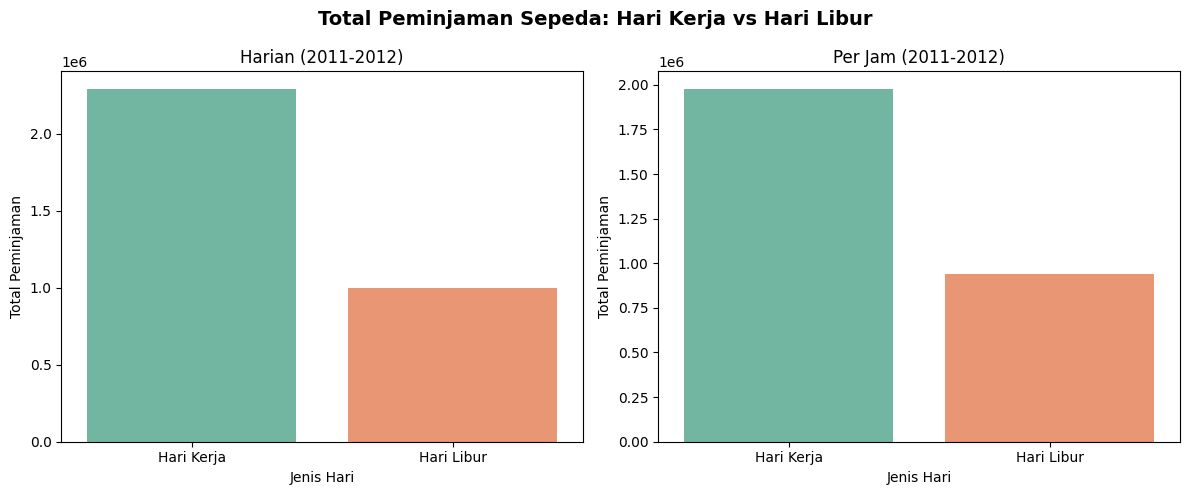

✅ visualisasi_pertanyaan1.png berhasil disimpan!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=hasil_1_day, x='Jenis Hari', y='Total', hue='Jenis Hari', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Harian (2011-2012)')
axes[0].set_xlabel('Jenis Hari')
axes[0].set_ylabel('Total Peminjaman')

sns.barplot(data=hasil_1_hour, x='Jenis Hari', y='Total', hue='Jenis Hari', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Per Jam (2011-2012)')
axes[1].set_xlabel('Jenis Hari')
axes[1].set_ylabel('Total Peminjaman')

fig.suptitle('Total Peminjaman Sepeda: Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisasi_pertanyaan1.png', dpi=150)
plt.show()
print("✅ visualisasi_pertanyaan1.png berhasil disimpan!")

### Pertanyaan 2: Pada musim apa jumlah total peminjaman sepeda paling tinggi dan paling rendah sepanjang tahun 2011-2012 untuk menentukan strategi promosi dan pemeliharaan armada?



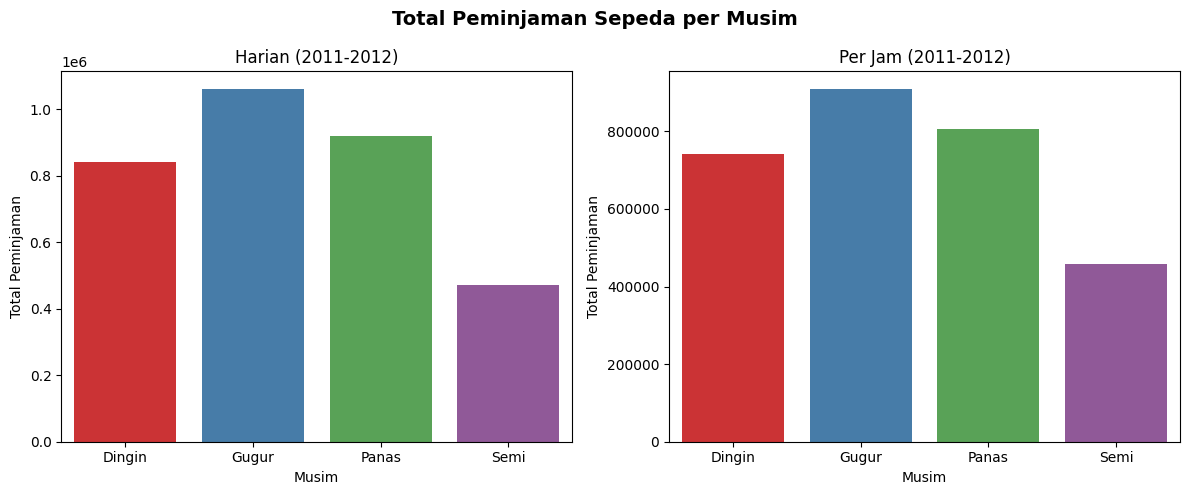

✅ visualisasi_pertanyaan2.png berhasil disimpan!


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=hasil_2_day, x='Musim', y='Total', hue='Musim', palette='Set1', legend=False, ax=axes[0])
axes[0].set_title('Harian (2011-2012)')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Total Peminjaman')

sns.barplot(data=hasil_2_hour, x='Musim', y='Total', hue='Musim', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Per Jam (2011-2012)')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Total Peminjaman')

fig.suptitle('Total Peminjaman Sepeda per Musim', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisasi_pertanyaan2.png', dpi=150)
plt.show()
print("✅ visualisasi_pertanyaan2.png berhasil disimpan!")

**Insight:** (Opsional)

Pertanyaan 1 — Hari Kerja vs Hari Libur
- Visualisasi bar chart berdampingan menunjukkan Hari Kerja selalu lebih tinggi dibanding Hari Libur baik data harian maupun per jam
- Sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah

Pertanyaan 2 — Per Musim
- Visualisasi bar chart berdampingan menunjukkan Musim Gugur tertinggi dan Musim Semi terendah baik data harian maupun per jam
- Kondisi cuaca di musim gugur lebih nyaman dan mendukung aktivitas bersepeda

## Conclusion & Recommendation

##Conclusion Pertanyaan 1:

Berdasarkan hasil analisis data peminjaman sepeda tahun 2011-2012, total peminjaman pada Hari Kerja jauh lebih tinggi dibanding Hari Libur baik pada data harian maupun per jam. Hal ini menunjukkan bahwa sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah dibandingkan untuk rekreasi di hari libur.

**Rekomendasi:**
Disarankan agar pengelola bike sharing menambah ketersediaan armada sepeda pada Hari Kerja untuk memenuhi tingginya permintaan. Selain itu, program promosi seperti diskon atau event bersepeda bersama perlu dibuat khusus untuk Hari Libur guna meningkatkan jumlah peminjaman pada periode sepi.

##Conclusion Pertanyaan 2:

Berdasarkan hasil analisis, Musim Gugur tercatat sebagai musim dengan total peminjaman tertinggi sedangkan Musim Semi menjadi yang terendah baik pada data harian maupun per jam. Hal ini mengindikasikan bahwa kondisi cuaca di musim gugur lebih nyaman dan mendukung aktivitas bersepeda dibanding musim lainnya.

**Rekomendasi:** Disarankan agar pengelola bike sharing menambah ketersediaan armada sepeda pada Musim Gugur karena permintaan paling tinggi pada periode tersebut. Jadwal pemeliharaan sepeda sebaiknya dilakukan pada Musim Semi karena peminjaman paling rendah sehingga tidak mengganggu operasional bisnis.